In [90]:
%%writefile requirements.txt
pandas
numpy
scikit-learn
matplotlib
seaborn
joblib

Overwriting requirements.txt


In [91]:
%%writefile .gitignore
# Python / Colab temporary files
.ipynb_checkpoints/
__pycache__/
*.pyc

# Virtual Environment
env/
venv/

# Large Datasets (اختر ما إذا كنت تريد رفع البيانات أم لا)
*.csv
*.zip

# Operating system files
.DS_Store
Thumbs.db

Overwriting .gitignore


In [92]:
%%writefile README.md
#  House Price Prediction (ML Project)

A Machine Learning project built to predict residential house prices using structural features and advanced regression techniques.

##  Features
- **Data Cleaning & Handling Missing Values**: Imputed missing values and converted categorical data.
- **Exploratory Data Analysis (EDA)**: Visualized feature distributions and correlation with target price.
- **Model Training**: Evaluated multiple algorithms (Linear Regression, Decision Trees, Random Forest, XGBoost).
- **Overfitting Mitigation**: Tuned hyperparameters to bridge the gap between Train and Test accuracy.

##  Results
- **Test Score ($R^2$)**: 92.2%
- **RMSE**: ~20,652

##  How to Run
1. Clone the repository:
   ```bash
   git clone [https://github.com/your-username/house-price-prediction.git](https://github.com/your-username/house-price-prediction.git)

Overwriting README.md


In [93]:
pip install -r requirements.txt

In [94]:
!pip install gradio

In [95]:
import gradio as gr
import numpy as np
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

X_train = np.array([[-2, -1], [-1, -1], [1, 1], [2, 1]])
y_train = np.array([0, 0, 1, 1])

clf1 = LogisticRegression()
clf2 = RandomForestClassifier(n_estimators=10)
clf3 = GaussianNB()

eclf = VotingClassifier(
    estimators=[('lr', clf1), ('rf', clf2), ('gnb', clf3)],
    voting='soft'
)
eclf.fit(X_train, y_train)

def predict_class(x1, x2):
    if x1 is None or x2 is None:
        return "⚠️ يرجى إدخال القيم في كلا الخانتين."

    try:
        input_data = np.array([[float(x1), float(x2)]])

        prediction = eclf.predict(input_data)[0]
        probabilities = eclf.predict_proba(input_data)[0]

        prob_class1 = round(probabilities[0] * 100, 2)
        prob_class2 = round(probabilities[1] * 100, 2)

        return f"الفئة المتوقعة: Class {prediction}\nاحتمالية Class 1: {prob_class1}%\nاحتمالية Class 2: {prob_class2}%"

    except Exception as e:
        return f" حدث خطأ برمجي:\n{str(e)}"

demo = gr.Interface(
    fn=predict_class,
    inputs=[
        gr.Number(label="الميزة الأولى (X1)", value=1.0),
        gr.Number(label="الميزة الثانية (X2)", value=1.0)
    ],
    outputs=gr.Textbox(label="نتيجة التصنيف (Prediction)"),
    title=" Voting Classifier Demo",
    examples=[[-2.0, -1.0], [2.0, 1.0]]
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4599d813dece55c968.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## Read Important Libraries

In [96]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as  plt
import seaborn as  sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import  confusion_matrix
import joblib

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 11,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

# Read The Files

In [97]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')
submission = pd.read_csv('sample_submission.csv')

In [98]:
train_df.shape


(1460, 81)

In [99]:
test_df.shape


(1459, 80)

In [100]:
submission.shape

(1459, 2)

In [101]:
print("--- 1. معلومات البيانات الأولية ---")
print(f"عدد الصفوف والأعمدة قبل التنظيف: {train_df.shape}")
print(f"عدد التكرارات بالكامل: {train_df.duplicated().sum()}")
print(f"إجمالي القيم المفقودة: {train_df.isnull().sum().sum()}")

--- 1. معلومات البيانات الأولية ---
عدد الصفوف والأعمدة قبل التنظيف: (1460, 81)
عدد التكرارات بالكامل: 0
إجمالي القيم المفقودة: 7829


In [102]:
# Check missing values
missing = train_df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(train_df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage (%)': missing_pct})
print(missing_df)

              Missing Count  Percentage (%)
PoolQC                 1453       99.520548
MiscFeature            1406       96.301370
Alley                  1369       93.767123
Fence                  1179       80.753425
MasVnrType              872       59.726027
FireplaceQu             690       47.260274
LotFrontage             259       17.739726
GarageType               81        5.547945
GarageYrBlt              81        5.547945
GarageFinish             81        5.547945
GarageQual               81        5.547945
GarageCond               81        5.547945
BsmtExposure             38        2.602740
BsmtFinType2             38        2.602740
BsmtQual                 37        2.534247
BsmtCond                 37        2.534247
BsmtFinType1             37        2.534247
MasVnrArea                8        0.547945
Electrical                1        0.068493


In [103]:
df_clean = train_df.copy()

In [104]:
df_clean.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


## Data Cleaning  

---



# A. Outlier removal


In [105]:
outliers_index = df_clean[(df_clean['GrLivArea'] > 4000) & (df_clean['SalePrice'] < 300000)].index
print(f"\nتم تحديد وحذف القيم الشاذة (Outliers) عددها: {len(outliers_index)}")
df_clean = df_clean.drop(outliers_index).reset_index(drop=True)


تم تحديد وحذف القيم الشاذة (Outliers) عددها: 2


# 1. Drop Id column as it's just an identifier

In [106]:
df_clean = df_clean.drop(columns=['Id'])

In [107]:
cat_none_cols = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'MasVnrType'
]
for col in cat_none_cols:
    df_clean[col] = df_clean[col].fillna('None')

In [108]:
df_clean['LotFrontage'] = df_clean.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))

df_clean['GarageYrBlt'] = df_clean['GarageYrBlt'].fillna(df_clean['YearBuilt'])

df_clean['MasVnrArea'] = df_clean['MasVnrArea'].fillna(0)

df_clean['Electrical'] = df_clean['Electrical'].fillna(df_clean['Electrical'].mode()[0])

In [109]:
remaining_nulls = df_clean.isnull().sum().sum()
remaining_nulls

np.int64(0)

# Check duplicates


In [110]:
duplicates = df_clean.duplicated().sum()
print(f"Duplicate rows count: {duplicates}")

Duplicate rows count: 0


## EDA ("Expolatory Data Analysis")

Original Skewness: 1.8812964895244009
Log Skewness: 0.12157976050304879


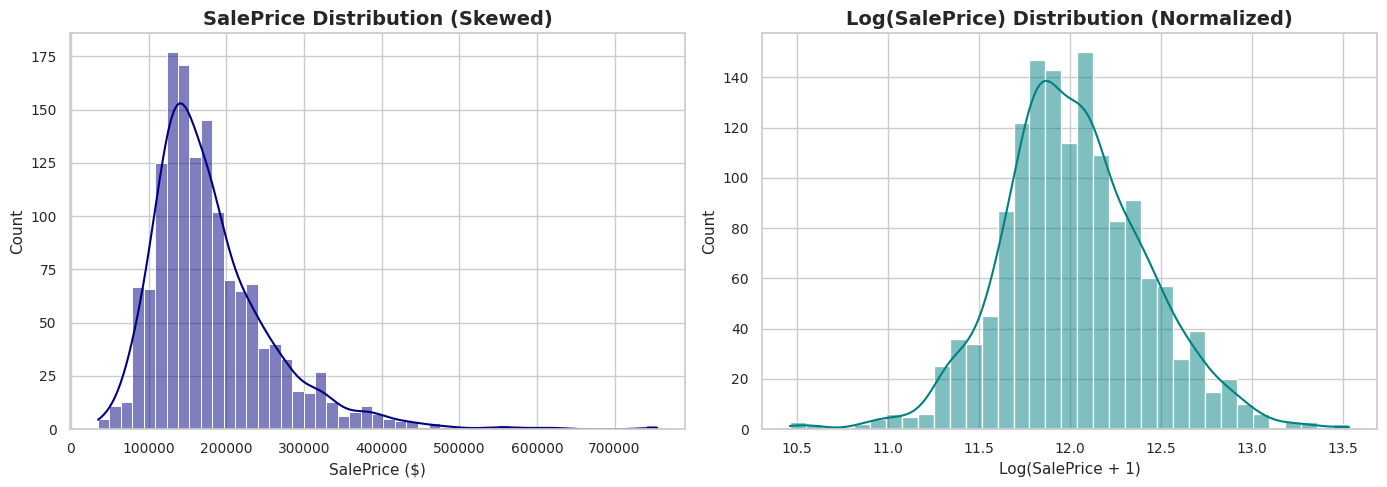

In [111]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_clean['SalePrice'], kde=True, ax=axes[0], color='navy')
axes[0].set_title('SalePrice Distribution (Skewed)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('SalePrice ($)')
axes[0].set_ylabel('Count')

sns.histplot(np.log1p(df_clean['SalePrice']), kde=True, ax=axes[1], color='teal')
axes[1].set_title('Log(SalePrice) Distribution (Normalized)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Log(SalePrice + 1)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('fig1_saleprice_dist.png', dpi=300)

df_clean['SalePrice_log'] = np.log1p(df_clean['SalePrice'])

print("Original Skewness:", df_clean['SalePrice'].skew())
print("Log Skewness:", df_clean['SalePrice_log'].skew())


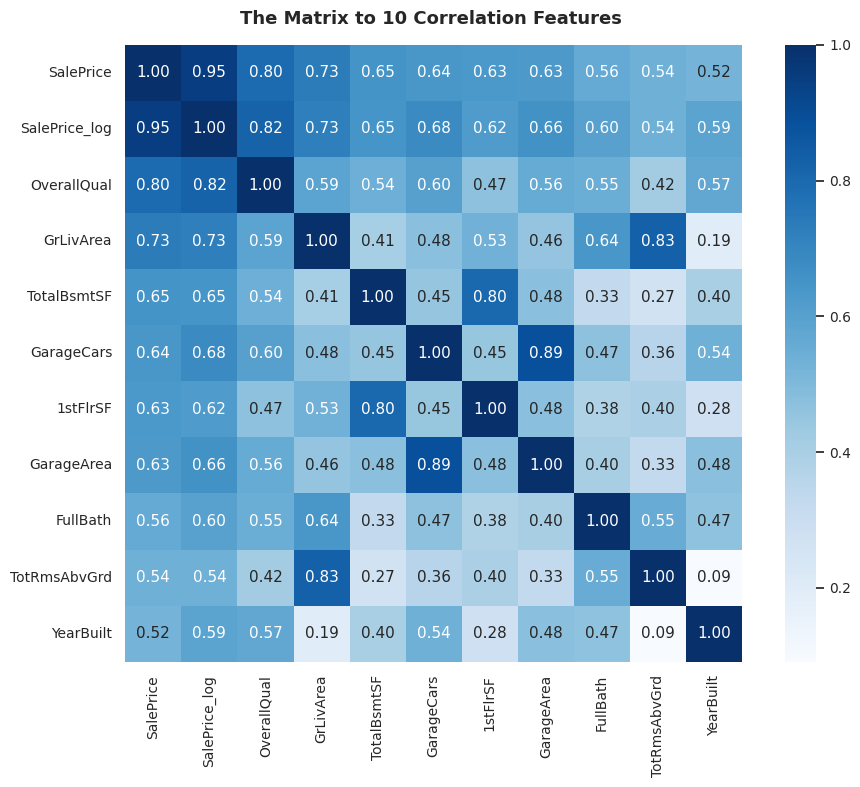

In [112]:
num_df = df_clean.select_dtypes(include=[np.number])
corr = num_df.corr()
top_corr_cols = corr['SalePrice'].abs().sort_values(ascending=False).head(11).index
plt.figure(figsize=(10, 8))
sns.heatmap(df_clean[top_corr_cols].corr(), annot=True, fmt='.2f', cmap='Blues', cbar=True, square=True)
plt.title('The Matrix to 10 Correlation Features ', fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('eda_2_correlation_heatmap.png', dpi=1000)

/tmp/ipykernel_2535/2144091834.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='OverallQual', y='SalePrice', data=df_clean, ax=axes[0, 0], palette='crest')
/tmp/ipykernel_2535/2144091834.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='SalePrice', y='Neighborhood', data=df_clean, order=neigh_order, ax=axes[1, 1], palette='viridis', errorbar=None)


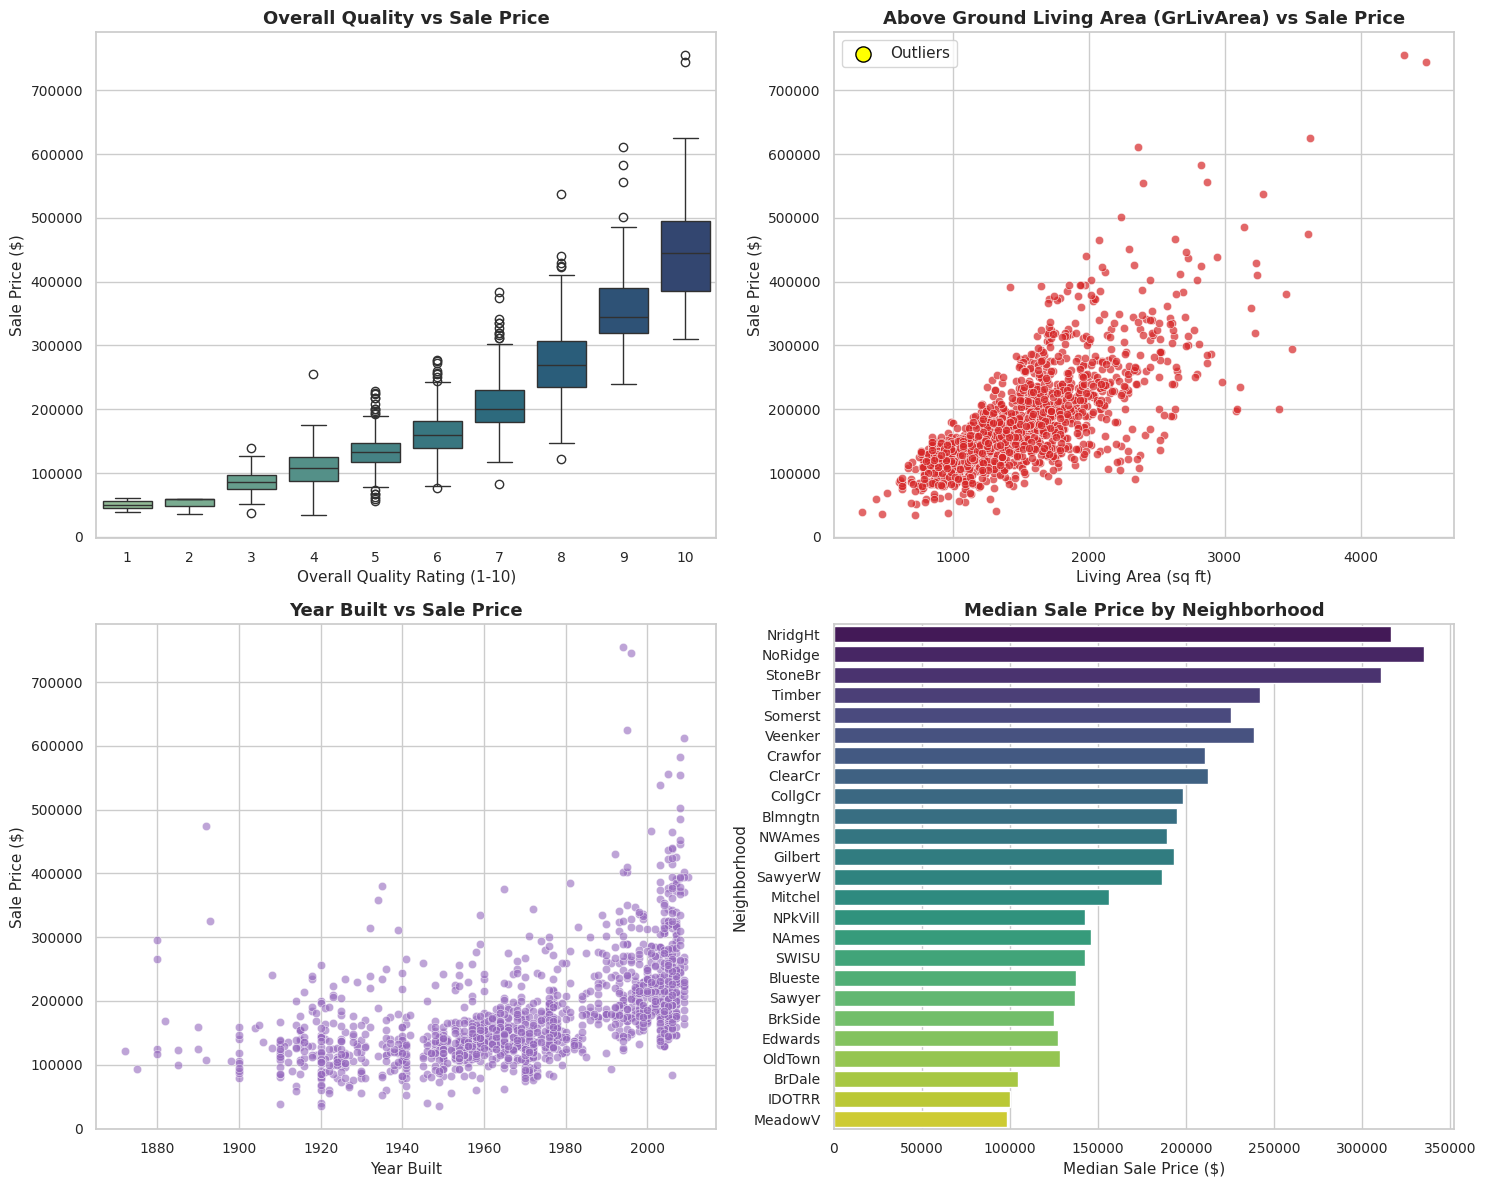

In [113]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

sns.boxplot(x='OverallQual', y='SalePrice', data=df_clean, ax=axes[0, 0], palette='crest')
axes[0, 0].set_title('Overall Quality vs Sale Price', fontweight='bold')
axes[0, 0].set_xlabel('Overall Quality Rating (1-10)')
axes[0, 0].set_ylabel('Sale Price ($)')

sns.scatterplot(x='GrLivArea', y='SalePrice', data=df_clean, ax=axes[0, 1], alpha=0.7, color='#d62728')
axes[0, 1].set_title('Above Ground Living Area (GrLivArea) vs Sale Price', fontweight='bold')
axes[0, 1].set_xlabel('Living Area (sq ft)')
axes[0, 1].set_ylabel('Sale Price ($)')

outliers = df_clean[(df_clean['GrLivArea'] > 4000) & (df_clean['SalePrice'] < 300000)]
axes[0, 1].scatter(outliers['GrLivArea'], outliers['SalePrice'], color='yellow', edgecolor='black', s=120, label='Outliers')
axes[0, 1].legend()

sns.scatterplot(x='YearBuilt', y='SalePrice', data=df_clean, ax=axes[1, 0], alpha=0.6, color='#9467bd')
axes[1, 0].set_title('Year Built vs Sale Price', fontweight='bold')
axes[1, 0].set_xlabel('Year Built')
axes[1, 0].set_ylabel('Sale Price ($)')

neigh_order = df_clean.groupby('Neighborhood')['SalePrice'].median().sort_values(ascending=False).index
sns.barplot(x='SalePrice', y='Neighborhood', data=df_clean, order=neigh_order, ax=axes[1, 1], palette='viridis', errorbar=None)
axes[1, 1].set_title('Median Sale Price by Neighborhood', fontweight='bold')
axes[1, 1].set_xlabel('Median Sale Price ($)')
axes[1, 1].set_ylabel('Neighborhood')

plt.tight_layout()
plt.savefig('eda_3_key_relationships_en.png', dpi=1000)
plt.show()

/tmp/ipykernel_2535/126148405.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='TotalBaths', y='SalePrice', data=df_clean, ax=axes[2], palette='Blues')


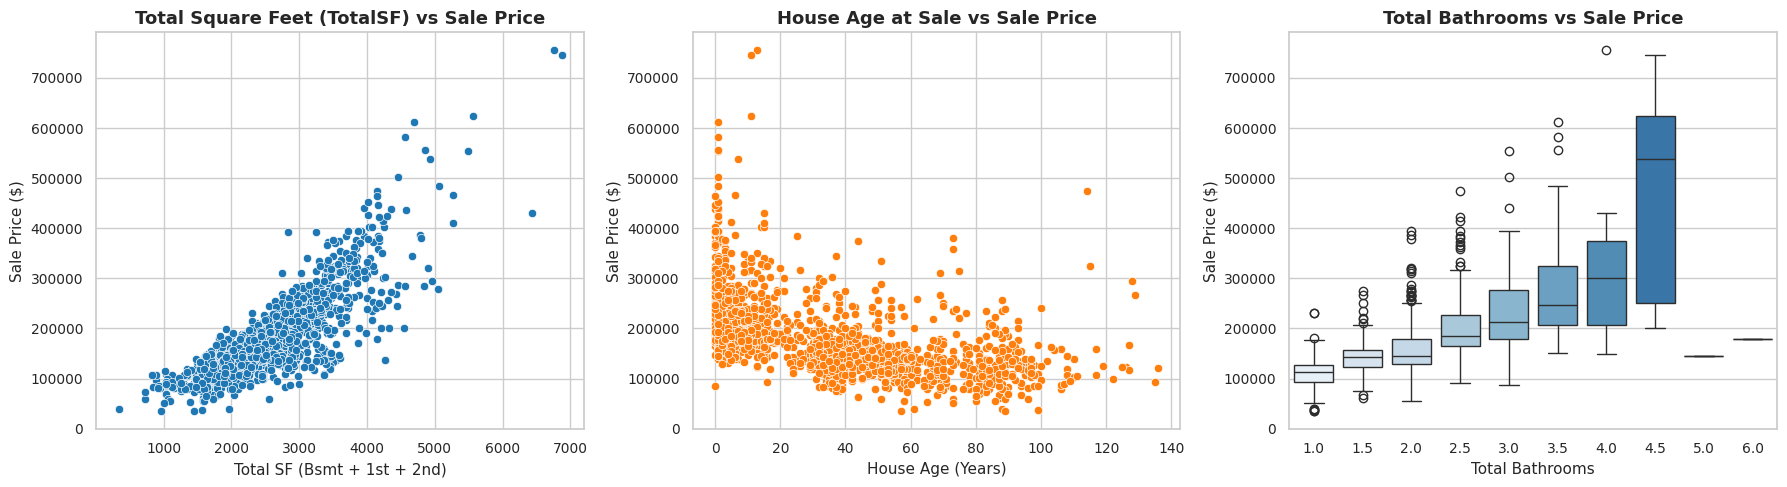

In [114]:
df_clean['TotalSF'] = df_clean['TotalBsmtSF'] + df_clean['1stFlrSF'] + df_clean['2ndFlrSF']
df_clean['HouseAge'] = df_clean['YrSold'] - df_clean['YearBuilt']
df_clean['TotalBaths'] = df_clean['FullBath'] + (0.5 * df_clean['HalfBath']) + df_clean['BsmtFullBath'] + (0.5 * df_clean['BsmtHalfBath'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(x='TotalSF', y='SalePrice', data=df_clean, ax=axes[0], alpha=1, color='#1f77b4')
axes[0].set_title('Total Square Feet (TotalSF) vs Sale Price', fontweight='bold')
axes[0].set_xlabel('Total SF (Bsmt + 1st + 2nd)')
axes[0].set_ylabel('Sale Price ($)')

sns.scatterplot(x='HouseAge', y='SalePrice', data=df_clean, ax=axes[1], alpha=1, color='#ff7f0e')
axes[1].set_title('House Age at Sale vs Sale Price', fontweight='bold')
axes[1].set_xlabel('House Age (Years)')
axes[1].set_ylabel('Sale Price ($)')

sns.boxplot(x='TotalBaths', y='SalePrice', data=df_clean, ax=axes[2], palette='Blues')
axes[2].set_title('Total Bathrooms vs Sale Price', fontweight='bold')
axes[2].set_xlabel('Total Bathrooms')
axes[2].set_ylabel('Sale Price ($)')

plt.tight_layout()
plt.savefig('eda_4_engineered_features.png', dpi=800)

In [115]:
print("TotalSF Corr:", df_clean['TotalSF'].corr(df_clean['SalePrice']))
print("GrLivArea Corr:", df_clean['GrLivArea'].corr(df_clean['SalePrice']))
print("TotalBsmtSF Corr:", df_clean['TotalBsmtSF'].corr(df_clean['SalePrice']))

TotalSF Corr: 0.8328770355221619
GrLivArea Corr: 0.7349681645359327
TotalBsmtSF Corr: 0.6511529110475417


/tmp/ipykernel_2535/2877036782.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='MoSold', y='count', data=month_data, ax=axes[0], palette='magma')


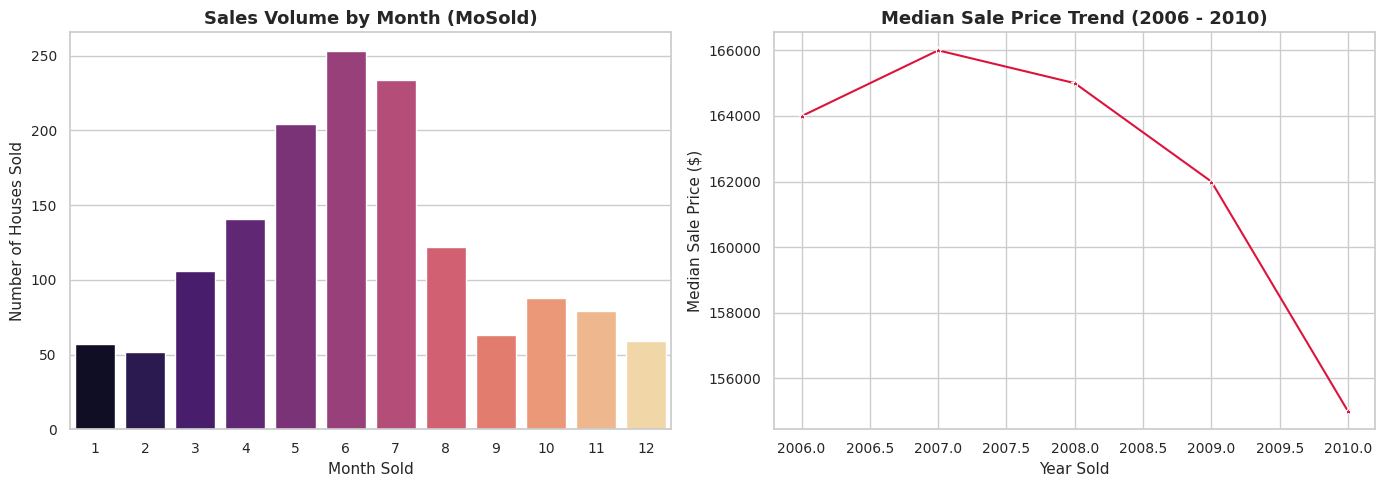

In [116]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

month_data = df_clean.groupby('MoSold')['SalePrice'].agg(['count', 'median']).reset_index()
sns.barplot(x='MoSold', y='count', data=month_data, ax=axes[0], palette='magma')
axes[0].set_title('Sales Volume by Month (MoSold)', fontweight='bold')
axes[0].set_xlabel('Month Sold')
axes[0].set_ylabel('Number of Houses Sold')

sns.lineplot(x='YrSold', y='SalePrice', data=df_clean, ax=axes[1], marker='*', color='crimson', estimator='median', errorbar=None)
axes[1].set_title('Median Sale Price Trend (2006 - 2010)', fontweight='bold')
axes[1].set_xlabel('Year Sold')
axes[1].set_ylabel('Median Sale Price ($)')

plt.tight_layout()
plt.savefig('eda_5_temporal_analysis.png', dpi=1000)

/tmp/ipykernel_2535/458596846.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='MSZoning', y='SalePrice', data=df_clean, ax=axes[0], palette='Set2')
/tmp/ipykernel_2535/458596846.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='SaleCondition', y='SalePrice', data=df_clean, ax=axes[1], palette='Set3')


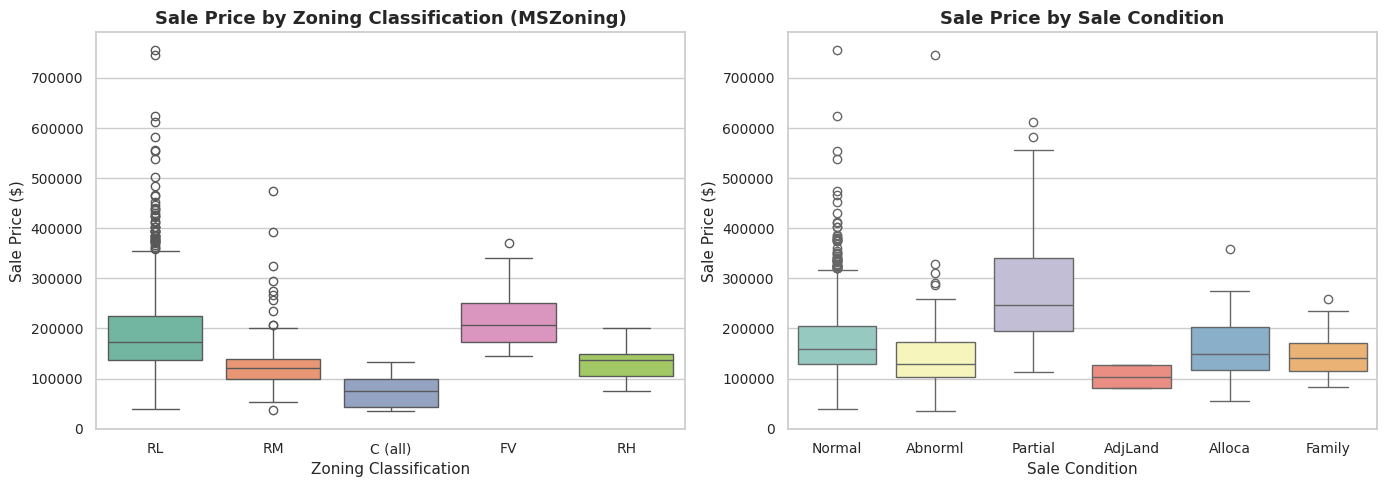

In [117]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='MSZoning', y='SalePrice', data=df_clean, ax=axes[0], palette='Set2')
axes[0].set_title('Sale Price by Zoning Classification (MSZoning)', fontweight='bold')
axes[0].set_xlabel('Zoning Classification')
axes[0].set_ylabel('Sale Price ($)')


sns.boxplot(x='SaleCondition', y='SalePrice', data=df_clean, ax=axes[1], palette='Set3')
axes[1].set_title('Sale Price by Sale Condition', fontweight='bold')
axes[1].set_xlabel('Sale Condition')
axes[1].set_ylabel('Sale Price ($)')

plt.tight_layout()
plt.savefig('eda_6_zoning_conditions.png', dpi=1000)

/tmp/ipykernel_2535/4262760056.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='CentralAir', y='SalePrice', data= df_clean, ax=axes[1], palette='coolwarm')


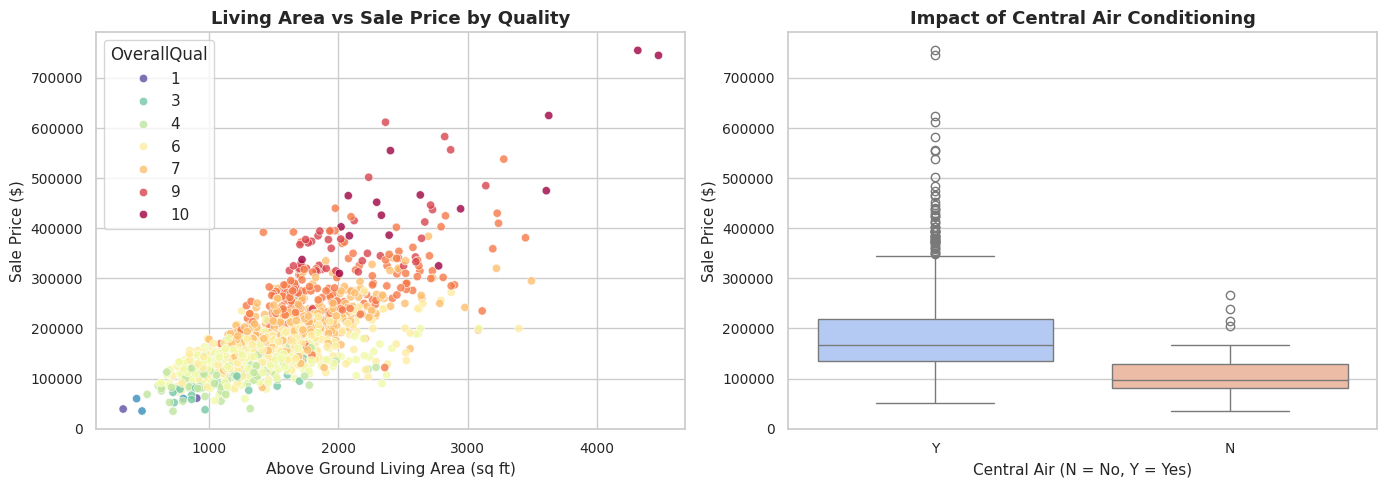

In [118]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x='GrLivArea', y='SalePrice', hue='OverallQual', data=df_clean, ax=axes[0], palette='Spectral_r', alpha=0.8)
axes[0].set_title('Living Area vs Sale Price by Quality', fontweight='bold')
axes[0].set_xlabel('Above Ground Living Area (sq ft)')
axes[0].set_ylabel('Sale Price ($)')

sns.boxplot(x='CentralAir', y='SalePrice', data= df_clean, ax=axes[1], palette='coolwarm')
axes[1].set_title('Impact of Central Air Conditioning', fontweight='bold')
axes[1].set_xlabel('Central Air (N = No, Y = Yes)')
axes[1].set_ylabel('Sale Price ($)')

plt.tight_layout()
plt.savefig('eda_7_interactions.png', dpi=1000)


# Identify numeric and categorical columns



In [119]:
num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
print("Numeric cols count:", len(num_cols))
print("Categorical cols count:", len(cat_cols))

Numeric cols count: 41
Categorical cols count: 43


In [120]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ]
)

df_clean_processed = preprocessor.fit_transform(df_clean)
print("Processed X shape:", df_clean_processed.shape)

Processed X shape: (1458, 306)


In [121]:
feature_names = preprocessor.get_feature_names_out()
df_processed_df = pd.DataFrame(df_clean_processed, columns=feature_names)
df_processed_df.describe()

,num__MSSubClass,num__LotFrontage,num__LotArea,num__OverallQual,num__OverallCond,num__YearBuilt,num__YearRemodAdd,num__MasVnrArea,num__BsmtFinSF1,num__BsmtFinSF2,...,cat__SaleType_ConLw,cat__SaleType_New,cat__SaleType_Oth,cat__SaleType_WD,cat__SaleCondition_Abnorml,cat__SaleCondition_AdjLand,cat__SaleCondition_Alloca,cat__SaleCondition_Family,cat__SaleCondition_Normal,cat__SaleCondition_Partial
count,1458.000000,1458.000000,1458.000000,1458.000000,1458.000000,1458.000000,1458.000000,1458.000000,1458.000000,1458.000000,...,1458.000000,1458.000000,1458.000000,1458.000000,1458.000000,1458.000000,1458.000000,1458.000000,1458.000000,1458.000000
mean,0.137860,-0.000669,0.242864,0.046982,0.576132,-0.027867,-0.247729,0.624061,0.079926,46.613169,...,0.003429,0.082305,0.002058,0.868999,0.069273,0.002743,0.008230,0.013717,0.821674,0.084362
std,0.846589,1.073519,2.431068,0.688184,1.113359,0.656386,0.557885,1.093801,0.608958,161.420729,...,0.058480,0.274922,0.045330,0.337518,0.254005,0.052324,0.090379,0.116355,0.382919,0.278026
min,-0.600000,-2.450000,-2.015781,-2.500000,-4.000000,-2.184783,-1.189189,0.000000,-0.537271,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-0.600000,-0.500000,-0.476020,-0.500000,0.000000,-0.402174,-0.729730,0.000000,-0.537271,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,0.400000,0.500000,0.523980,0.500000,1.000000,0.597826,0.270270,1.000000,0.462729,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,2.800000,12.150000,50.738503,2.000000,4.000000,0.815217,0.432432,9.770992,2.540084,1474.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Spliting  The Data

In [122]:
X = df_clean.drop(columns=['SalePrice', 'SalePrice_log', 'Id'], errors='ignore')
y = df_clean['SalePrice']

In [123]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1166, 82)
(292, 82)
(1166,)
(292,)


In [124]:
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"{'n_estimators':<15} | {'Val RMSE':<15} | {'Val R2':<10}")
print("-" * 48)
for n in range(1, 100, 10):
    House = GradientBoostingRegressor(n_estimators=n, learning_rate=0.1, max_depth=3, random_state=42)
    House.fit(X_train_processed, y_train)
    y_pred = House.predict(X_test_processed)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(f"{n:<15} | {rmse:<15.2f} | {r2:<10.4f}")


n_estimators    | Val RMSE        | Val R2    
------------------------------------------------
1               | 68452.54        | 0.1517    
11              | 36744.26        | 0.7556    
21              | 27178.56        | 0.8663    
31              | 23839.86        | 0.8971    
41              | 22526.55        | 0.9081    
51              | 21886.81        | 0.9133    
61              | 21434.28        | 0.9168    
71              | 21214.23        | 0.9185    
81              | 21013.01        | 0.9201    
91              | 20875.85        | 0.9211    


In [126]:
y_pred = House.predict(X_test_processed)
print(y_pred[:10])
print(y_test[:10])

print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("The Score is in test =", House.score(X_test_processed, y_test))
print("The Score is in Train =", House.score(X_train_processed, y_train))

[211427.21085076 109503.81734891 110862.1662176  150340.97035363
 326188.64495091 136342.06601987 214832.00721291 327260.69788864
 271242.55222623 138059.91173805]
1320    190000
836     100000
413     115000
522     159000
1035    315500
614     137500
218     311500
1031    310000
1288    281000
886     135500
Name: SalePrice, dtype: int64
MSE: 435801146.96194655
RMSE: 20875.850808097537
The Score is in test = 0.9211037912111529
The Score is in Train = 0.9732037143185797
